# Análise Q1-Q9 — comorbidade, atraso e letalidade nas arboviroses

## Fonte: `casos_arboviroses.parquet` (local, sem MongoDB)

Mesma lógica de análise das versões anteriores, agora em pandas puro sobre o arquivo gerado por `extrair_dataset.py`. Schema flat: uma coluna booleana por comorbidade (`diabetes`, `hipertensao`, `hepatopatia`, `doenca_renal_cronica`, `doenca_hematologica`, `doenca_acido_peptica`, `doenca_autoimune`) em vez de lista aninhada.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import chi2 as chi2_dist

sns.set_theme(style="whitegrid", context="talk", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Carregar dados e definir constantes de exibição

In [30]:
df = pd.read_parquet("casos_arboviroses.parquet")
print(f"{len(df):,} linhas carregadas")
df.groupby("doenca").size()

df["hospitalizado"] = df["hospitalizado"].astype("boolean")
df["grave_ou_internado"] = df["grave_ou_internado"].astype("boolean")

13,113,270 linhas carregadas


In [31]:
ORDEM_DOENCAS = ["dengue", "chikungunya", "zika", "febre_amarela"]
ROTULO_DOENCA = {
    "dengue": "Dengue", "chikungunya": "Chikungunya",
    "zika": "Zika", "febre_amarela": "Febre amarela",
}
CORES_DOENCA = {
    "dengue": "#e63946", "chikungunya": "#f4a261",
    "zika": "#2a9d8f", "febre_amarela": "#6a040f",
}
ORDEM_FAIXAS = ["<1", "1-4", "5-11", "12-19", "20-39", "40-59", "60+"]
COLUNAS_COMORBIDADE = ["diabetes", "hipertensao", "hepatopatia", "doenca_renal_cronica",
                       "doenca_hematologica", "doenca_acido_peptica", "doenca_autoimune"]

df["faixa_etaria"] = pd.Categorical(df["faixa_etaria"], categories=ORDEM_FAIXAS, ordered=True)

# Escopo usado em Q1-Q7 e na secao 11: dengue/chikungunya, excluindo
# descartado/inconclusivo (sao desfecho de classificacao, nao gravidade),
# restrito a quem tem dado de comorbidade preenchido (n_comorbidades notna)
escopo_comorb = df[
    df["doenca"].isin(["dengue", "chikungunya"]) &
    ~df["classificacao"].isin(["descartado", "inconclusivo"]) &
    df["n_comorbidades"].notna()
].copy()
escopo_comorb["tem_comorbidade"] = escopo_comorb["n_comorbidades"] > 0
print(f"Escopo comorbidade: {len(escopo_comorb):,} linhas")

Escopo comorbidade: 11,314,051 linhas


## Painel de indicadores por doença (visão de abertura)

In [32]:
painel = df.groupby("doenca").agg(
    n_casos=("doenca", "size"),
    idade_mediana=("idade", "median"),
    pct_masculino=("sexo", lambda s: (s == "masculino").mean() * 100),
    pct_obito=("obito", lambda s: s.mean() * 100),
).reindex(ORDEM_DOENCAS)
painel.index = painel.index.map(ROTULO_DOENCA)
painel.round(2)

,n_casos,idade_mediana,pct_masculino,pct_obito
doenca,,,,
Dengue,11648980,34.0,45.52,0.12
Chikungunya,1315829,37.0,40.81,0.21
Zika,148308,30.0,39.45,0.46
Febre amarela,153,43.0,90.85,42.48


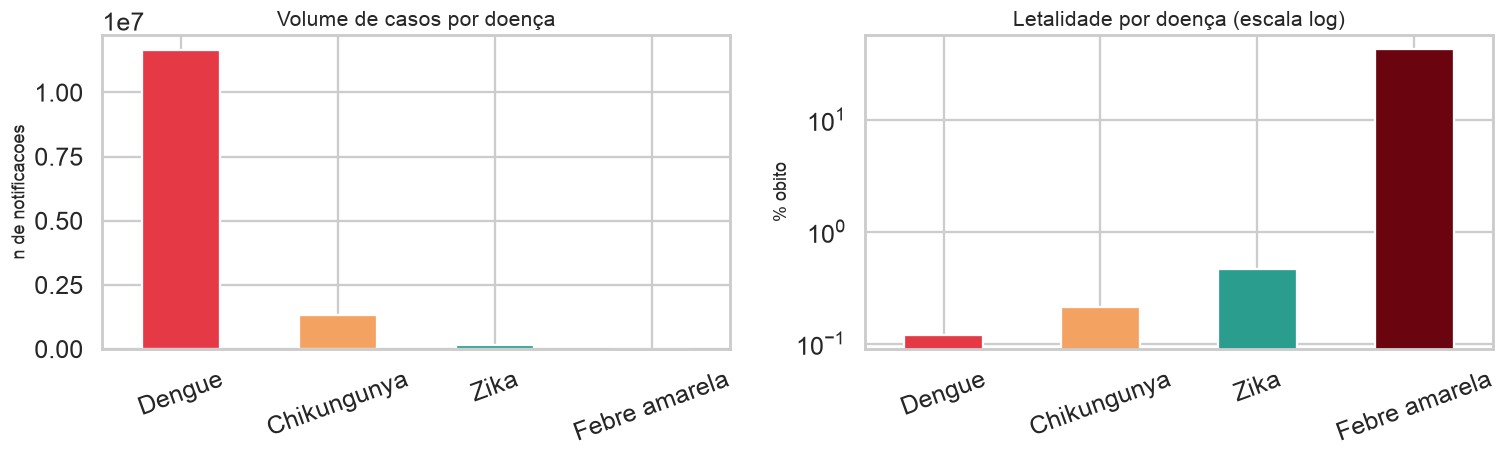

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cores = [CORES_DOENCA[d] for d in ORDEM_DOENCAS]

painel["n_casos"].plot(kind="bar", ax=axes[0], color=cores)
axes[0].set(title="Volume de casos por doença", ylabel="n de notificacoes", xlabel="")
axes[0].tick_params(axis="x", rotation=20)

painel["pct_obito"].plot(kind="bar", ax=axes[1], color=cores, logy=True)
axes[1].set(title="Letalidade por doença (escala log)", ylabel="% obito", xlabel="")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

> **Leitura esperada:** a dengue domina em volume, mas a febre amarela domina em letalidade por ordens de grandeza — a escala logarítmica existe por causa desse contraste, não por estética. Febre amarela tem poucos casos no período (n pequeno), então qualquer proporção envolvendo ela tem intervalo de confiança largo.

## Q1 — Comorbidade vs gravidade/internação

                    size  pct_grave_internado
tem_comorbidade                              
False            9859828                  3.0
True             1454223                  6.7


/var/folders/pw/nqwvql6164q9zxdc1g2j406w0000gn/T/ipykernel_68798/807585086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q1.index.map({False: "Não", True: "Sim"}), y=q1["pct_grave_internado"],


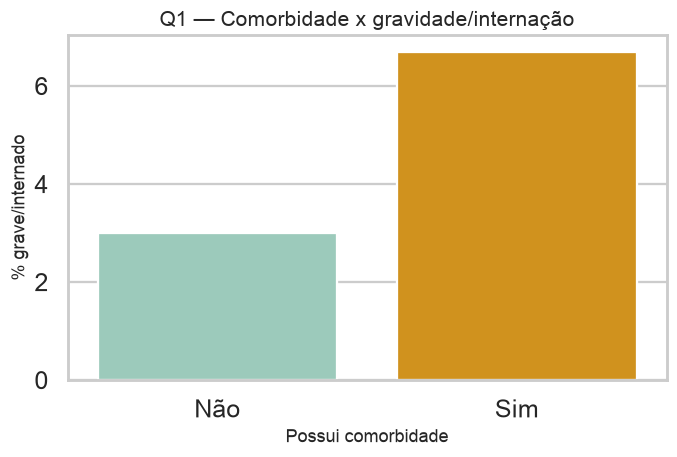

In [34]:
base_q1 = escopo_comorb[escopo_comorb["grave_ou_internado"].notna()].copy()
base_q1["grave_ou_internado"] = base_q1["grave_ou_internado"].astype(bool)

for col in ["gravidade", "hospitalizado", "grave_ou_internado"]:
    df[col] = df[col].where(df[col].notna(), None) 

q1 = base_q1.groupby("tem_comorbidade")["grave_ou_internado"].agg(["size", "mean"])
q1["pct_grave_internado"] = (q1["mean"] * 100).round(1)
print(q1[["size", "pct_grave_internado"]])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.barplot(x=q1.index.map({False: "Não", True: "Sim"}), y=q1["pct_grave_internado"],
            palette=["#94d2bd", "#ee9b00"], ax=ax)
ax.set(xlabel="Possui comorbidade", ylabel="% grave/internado",
       title="Q1 — Comorbidade x gravidade/internação")
plt.tight_layout(); plt.show()

## Q2 — Dose-resposta (multimorbidade)

   n_comorbidades     size      mean  erro_padrao
0             0.0  9859828  0.029604     0.000054
1             1.0  1074712  0.059853     0.000229
2             2.0   335203  0.085432     0.000483
3             3.0    26573  0.137433     0.002112
4             4.0     5583  0.077915     0.003587
5             5.0     1407  0.060412     0.006352
6             6.0     1233  0.033252     0.005106
7             7.0     9512  0.036060     0.001912


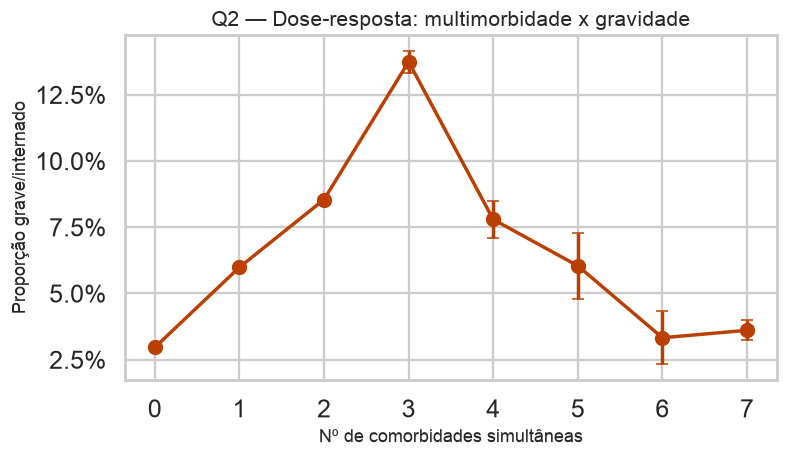

In [35]:
q2 = base_q1.groupby("n_comorbidades")["grave_ou_internado"].agg(["size", "mean"]).reset_index()
q2["erro_padrao"] = np.sqrt(q2["mean"] * (1 - q2["mean"]) / q2["size"])
print(q2)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(q2["n_comorbidades"], q2["mean"], yerr=1.96 * q2["erro_padrao"],
            fmt="o-", color="#bb3e03", capsize=4)
ax.set(xlabel="Nº de comorbidades simultâneas", ylabel="Proporção grave/internado",
       title="Q2 — Dose-resposta: multimorbidade x gravidade")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

## Q3 — Moderação por idade e sexo

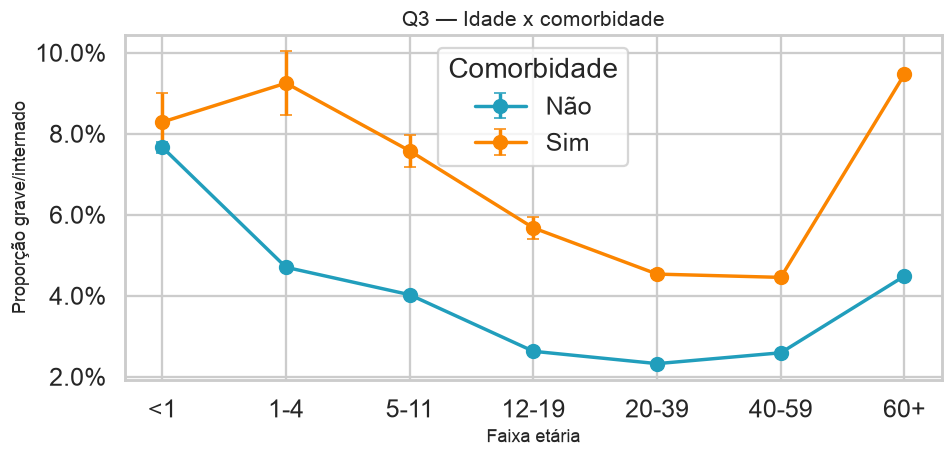

In [36]:
q3 = (base_q1.dropna(subset=["faixa_etaria"])
      .groupby(["faixa_etaria", "tem_comorbidade"], observed=True)["grave_ou_internado"]
      .agg(["size", "mean"]).reset_index())
q3["erro_padrao"] = np.sqrt(q3["mean"] * (1 - q3["mean"]) / q3["size"])

fig, ax = plt.subplots(figsize=(9, 4.5))
for tem, cor, rotulo in [(False, "#219ebc", "Não"), (True, "#fb8500", "Sim")]:
    sub = q3[q3["tem_comorbidade"] == tem].sort_values("faixa_etaria")
    ax.errorbar(sub["faixa_etaria"], sub["mean"], yerr=1.96 * sub["erro_padrao"],
                fmt="o-", color=cor, capsize=4, label=rotulo)
ax.set(xlabel="Faixa etária", ylabel="Proporção grave/internado", title="Q3 — Idade x comorbidade")
ax.legend(title="Comorbidade")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout(); plt.show()

## Q4 — Dengue vs chikungunya: a mesma comorbidade pesa igual?

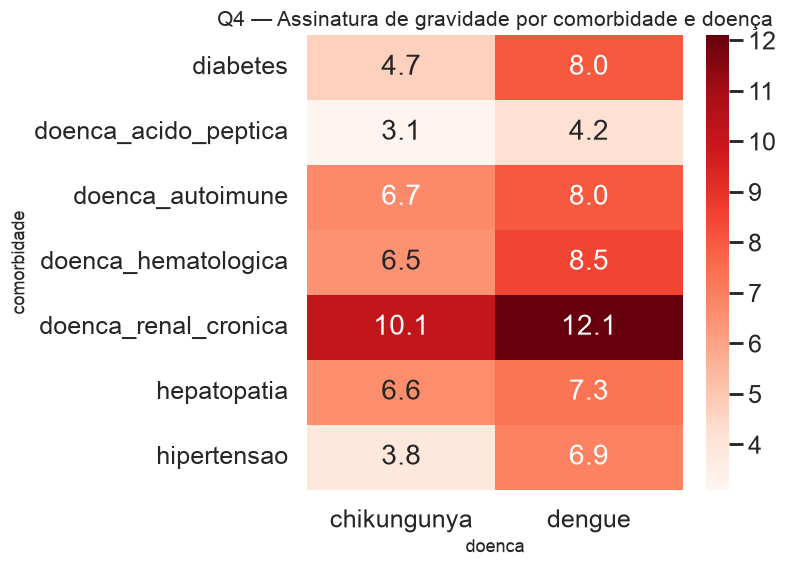

In [37]:
escopo_comorb = df[
    df["doenca"].isin(["dengue", "chikungunya"]) &
    ~df["classificacao"].isin(["descartado", "inconclusivo"]) &
    df["n_comorbidades"].notna()
].copy()

escopo_comorb["grave_ou_internado"] = escopo_comorb["grave_ou_internado"].astype("boolean")
escopo_comorb["hospitalizado"] = escopo_comorb["hospitalizado"].astype("boolean")
escopo_comorb["tem_comorbidade"] = escopo_comorb["n_comorbidades"] > 0

base_q4 = escopo_comorb[escopo_comorb["grave_ou_internado"].notna()]
long_comorb = base_q4.melt(
    id_vars=["doenca", "grave_ou_internado"], value_vars=COLUNAS_COMORBIDADE,
    var_name="comorbidade", value_name="presente"
)
long_comorb = long_comorb[long_comorb["presente"] == True]  # noqa: E712

q4 = long_comorb.groupby(["doenca", "comorbidade"])["grave_ou_internado"].mean().mul(100).round(1)
assinatura = q4.unstack("doenca")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
assinatura = q4.unstack("doenca").astype("float64")

sns.heatmap(assinatura, annot=True, fmt=".1f", cmap="Reds", ax=ax)
ax.set(title="Q4 — Assinatura de gravidade por comorbidade e doença")
plt.tight_layout(); plt.show()

## Q5 — Atraso por presença de comorbidade

Mann-Whitney precisa da distribuição real (não de um resumo), o que já temos direto no dataframe — sem passo extra de busca, diferente da versão Mongo.

/var/folders/pw/nqwvql6164q9zxdc1g2j406w0000gn/T/ipykernel_68798/893285842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base_q5, x="tem_comorbidade", y="atraso_dias", showfliers=False,
/var/folders/pw/nqwvql6164q9zxdc1g2j406w0000gn/T/ipykernel_68798/893285842.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Não", "Sim"])


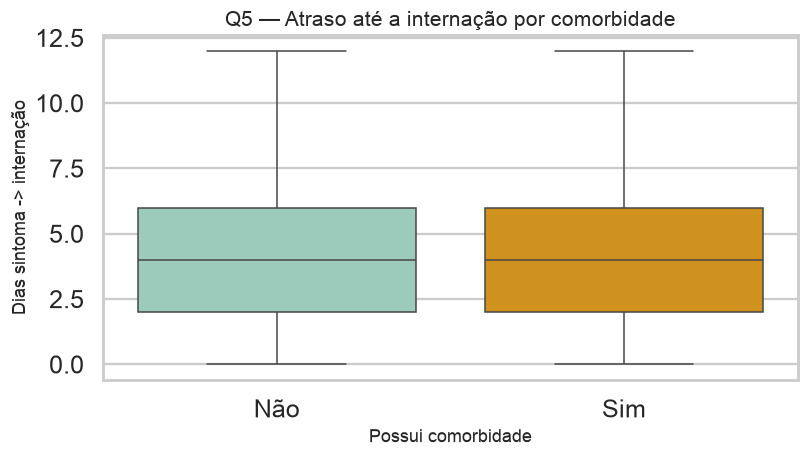

Mann-Whitney U: estatistica=10338299334.0, p=0.000104
Mediana sem comorbidade: 4.0 dias | com comorbidade: 4.0 dias


In [38]:
base_q5 = escopo_comorb[escopo_comorb["atraso_dias"].notna()]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(data=base_q5, x="tem_comorbidade", y="atraso_dias", showfliers=False,
            palette=["#94d2bd", "#ee9b00"], ax=ax)
ax.set(xlabel="Possui comorbidade", ylabel="Dias sintoma -> internação",
       title="Q5 — Atraso até a internação por comorbidade")
ax.set_xticklabels(["Não", "Sim"])
plt.tight_layout(); plt.show()

g_sem = base_q5[~base_q5["tem_comorbidade"]]["atraso_dias"]
g_com = base_q5[base_q5["tem_comorbidade"]]["atraso_dias"]
estat, p_valor = stats.mannwhitneyu(g_sem, g_com, alternative="two-sided")
print(f"Mann-Whitney U: estatistica={estat:.1f}, p={p_valor:.4g}")
print(f"Mediana sem comorbidade: {g_sem.median():.1f} dias | com comorbidade: {g_com.median():.1f} dias")

## Q6 — Atraso por idade e sexo, em cada doença (proxy específica por ficha)

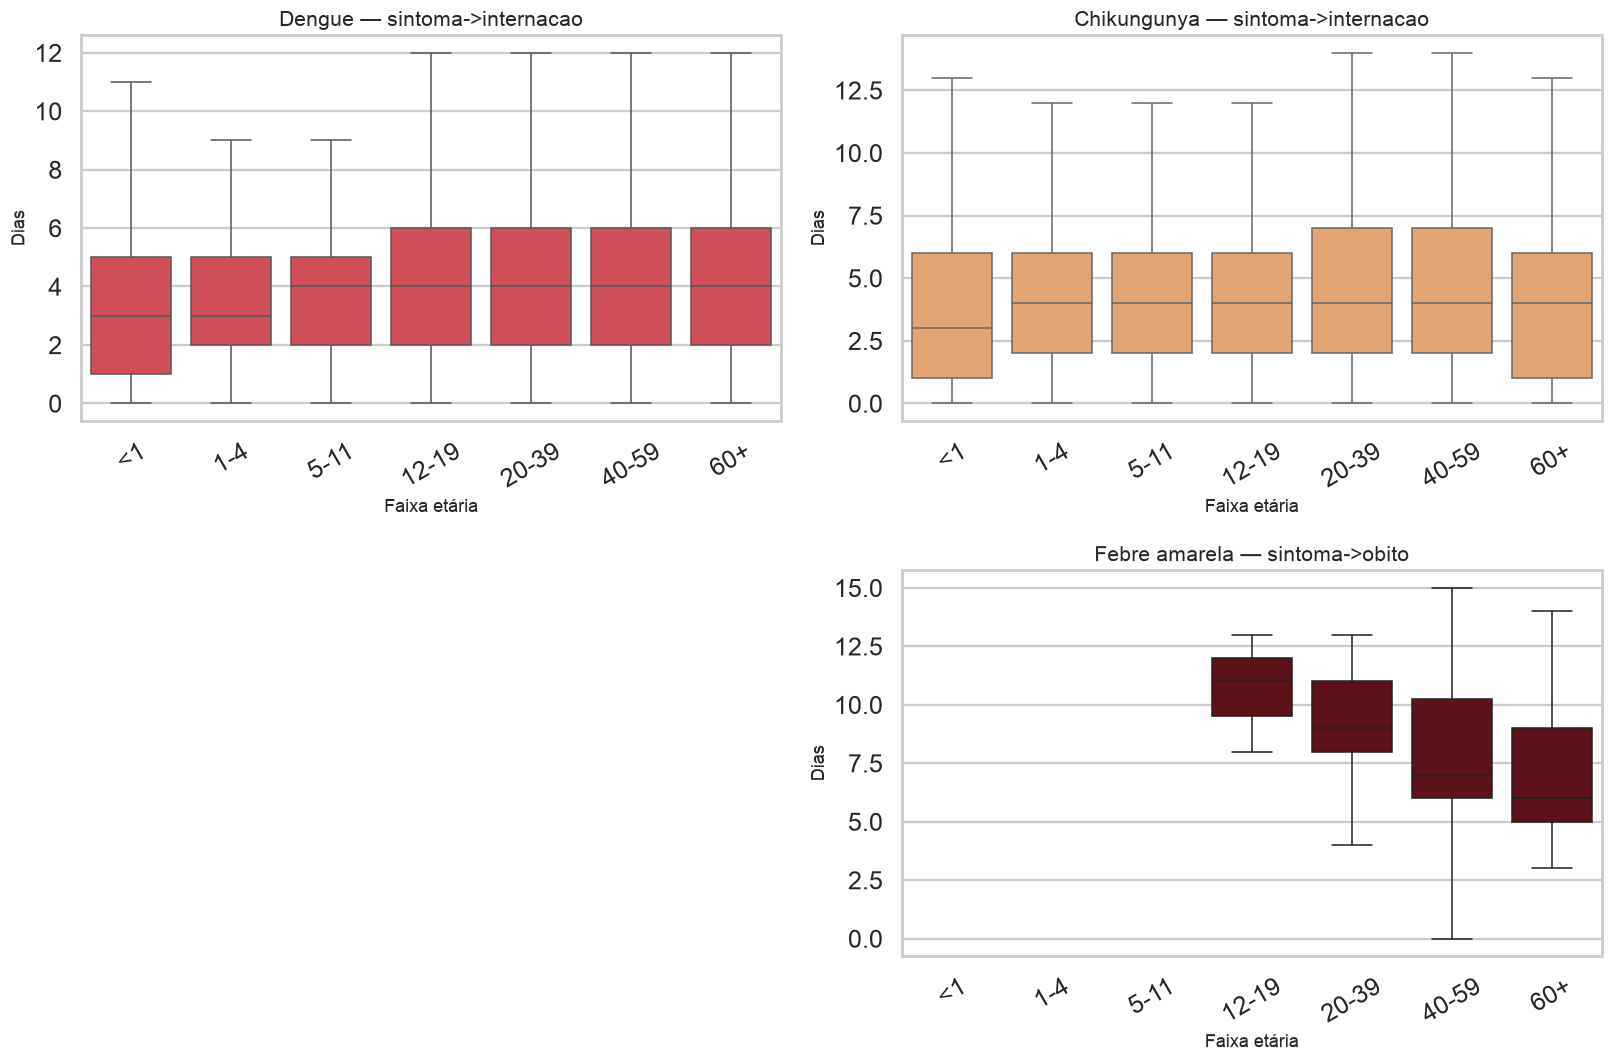

Q6 — teste de diferenca de atraso entre faixas etarias (Kruskal-Wallis) e por sexo (Mann-Whitney):

Dengue (faixa etaria): H=2064.16, p=0
Chikungunya (faixa etaria): H=198.85, p=3.331e-40
Zika: amostra insuficiente (n=0)
Febre amarela (faixa etaria): H=4.67, p=0.09695


In [39]:
base_q6 = df[df["atraso_dias"].notna()]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, doenca in zip(axes.ravel(), ORDEM_DOENCAS):
    sub = base_q6[base_q6["doenca"] == doenca].dropna(subset=["faixa_etaria"])
    if sub.empty:
        ax.set_visible(False)
        continue
    sns.boxplot(data=sub, x="faixa_etaria", y="atraso_dias", order=ORDEM_FAIXAS,
                showfliers=False, color=CORES_DOENCA[doenca], ax=ax)
    proxy = sub["atraso_proxy"].iloc[0]
    ax.set(title=f"{ROTULO_DOENCA[doenca]} — {proxy}", xlabel="Faixa etária", ylabel="Dias")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Q6 — teste de diferenca de atraso entre faixas etarias (Kruskal-Wallis) e por sexo (Mann-Whitney):\n")
for doenca in ORDEM_DOENCAS:
    sub = base_q6[base_q6["doenca"] == doenca]
    if len(sub) < 30:
        print(f"{ROTULO_DOENCA[doenca]}: amostra insuficiente (n={len(sub)})")
        continue
    grupos = [g["atraso_dias"].values for _, g in sub.groupby("faixa_etaria", observed=True) if len(g) > 5]
    if len(grupos) >= 2:
        kw_stat, kw_p = stats.kruskal(*grupos)
        print(f"{ROTULO_DOENCA[doenca]} (faixa etaria): H={kw_stat:.2f}, p={kw_p:.4g}")
    grupos_sexo = [g["atraso_dias"].values for _, g in sub.groupby("sexo") if len(g) > 5]
    if len(grupos_sexo) == 2:
        mw_stat, mw_p = stats.mannwhitneyu(*grupos_sexo, alternative="two-sided")
        print(f"{ROTULO_DOENCA[doenca]} (sexo): U={mw_stat:.1f}, p={mw_p:.4g}\n")

## Q7 — Entre internados, maior atraso até a internação prediz forma grave?

In [40]:
base_q7 = escopo_comorb[
    (escopo_comorb["hospitalizado"] == True) &
    escopo_comorb["atraso_dias"].notna() &
    escopo_comorb["gravidade"].notna()
].dropna(subset=["idade", "sexo"]).copy()
base_q7["grave"] = (base_q7["gravidade"] == "grave").astype(int)
base_q7["sexo_bin"] = (base_q7["sexo"] == "masculino").astype(int)

modelo_q7 = smf.logit("grave ~ atraso_dias + n_comorbidades + idade + sexo_bin", data=base_q7).fit(disp=0)
res_q7 = pd.DataFrame({
    "OR": np.exp(modelo_q7.params),
    "IC95%_low": np.exp(modelo_q7.conf_int()[0]),
    "IC95%_high": np.exp(modelo_q7.conf_int()[1]),
    "p_valor": modelo_q7.pvalues,
}).round(3)
res_q7

,OR,IC95%_low,IC95%_high,p_valor
Intercept,0.017,0.016,0.017,0.0
atraso_dias,1.019,1.015,1.023,0.0
n_comorbidades,1.463,1.433,1.493,0.0
idade,1.011,1.010,1.012,0.0
sexo_bin,1.097,1.058,1.138,0.0


> **Como interpretar:** o `OR` da linha `atraso_dias` é a razão de chances de evoluir pra forma grave por cada dia adicional entre sintoma e internação, já descontados comorbidade, idade e sexo.

## Q8 — Febre amarela: perfil de letalidade

Casos de febre amarela: 153 | letalidade geral: 42.5%

           total  pct_letalidade
sexo                            
feminino      14       28.571429
masculino    139       43.884892


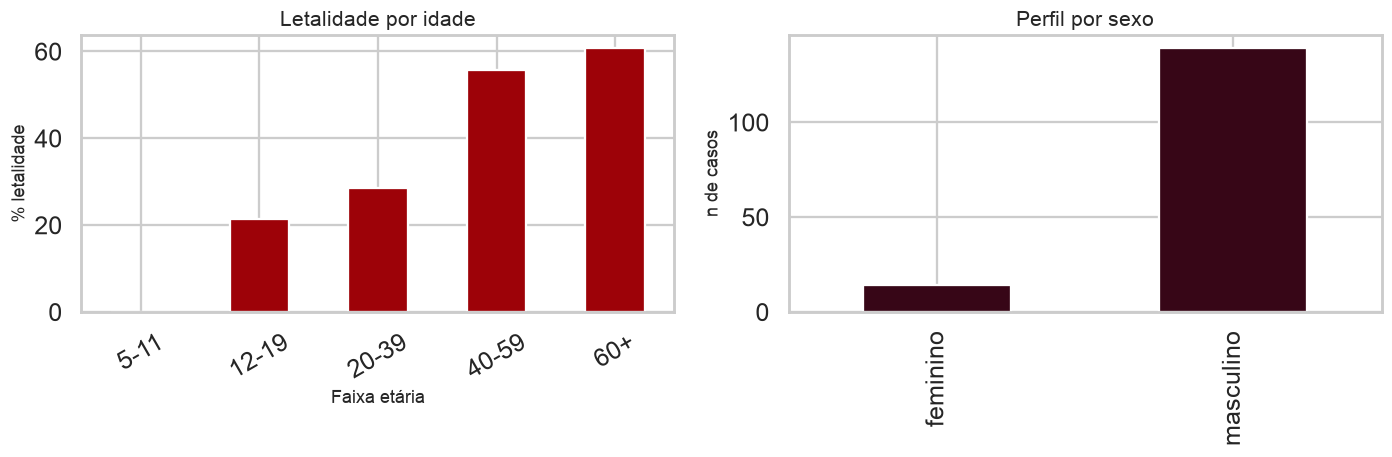

In [41]:
fa = df[df["doenca"] == "febre_amarela"]
print(f"Casos de febre amarela: {len(fa)} | letalidade geral: {fa['obito'].mean() * 100:.1f}%\n")

por_sexo = fa.groupby("sexo").agg(total=("obito", "size"), pct_letalidade=("obito", lambda s: s.mean() * 100))
print(por_sexo)

por_faixa = (fa.dropna(subset=["faixa_etaria"]).groupby("faixa_etaria", observed=True)
             .agg(total=("obito", "size"), pct_letalidade=("obito", lambda s: s.mean() * 100)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
por_faixa["pct_letalidade"].plot(kind="bar", ax=axes[0], color="#9d0208")
axes[0].set(ylabel="% letalidade", xlabel="Faixa etária", title="Letalidade por idade")
axes[0].tick_params(axis="x", rotation=30)

por_sexo["total"].plot(kind="bar", ax=axes[1], color="#370617")
axes[1].set(ylabel="n de casos", xlabel="", title="Perfil por sexo")
plt.tight_layout(); plt.show()

> **Hipótese ocupacional:** se a letalidade se concentrar em homens de 20-59 anos, é consistente com exposição rural/silvestre — a febre amarela não é transmitida pelo `Aedes` urbano, e sim por mosquitos de mata. **Atenção:** n é pequeno aqui (poucas centenas de casos no período), então as proporções por faixa/sexo têm intervalo de confiança largo — trate como indicativo, não conclusivo.

## Q9 — Comparativo de letalidade por idade nas quatro doenças

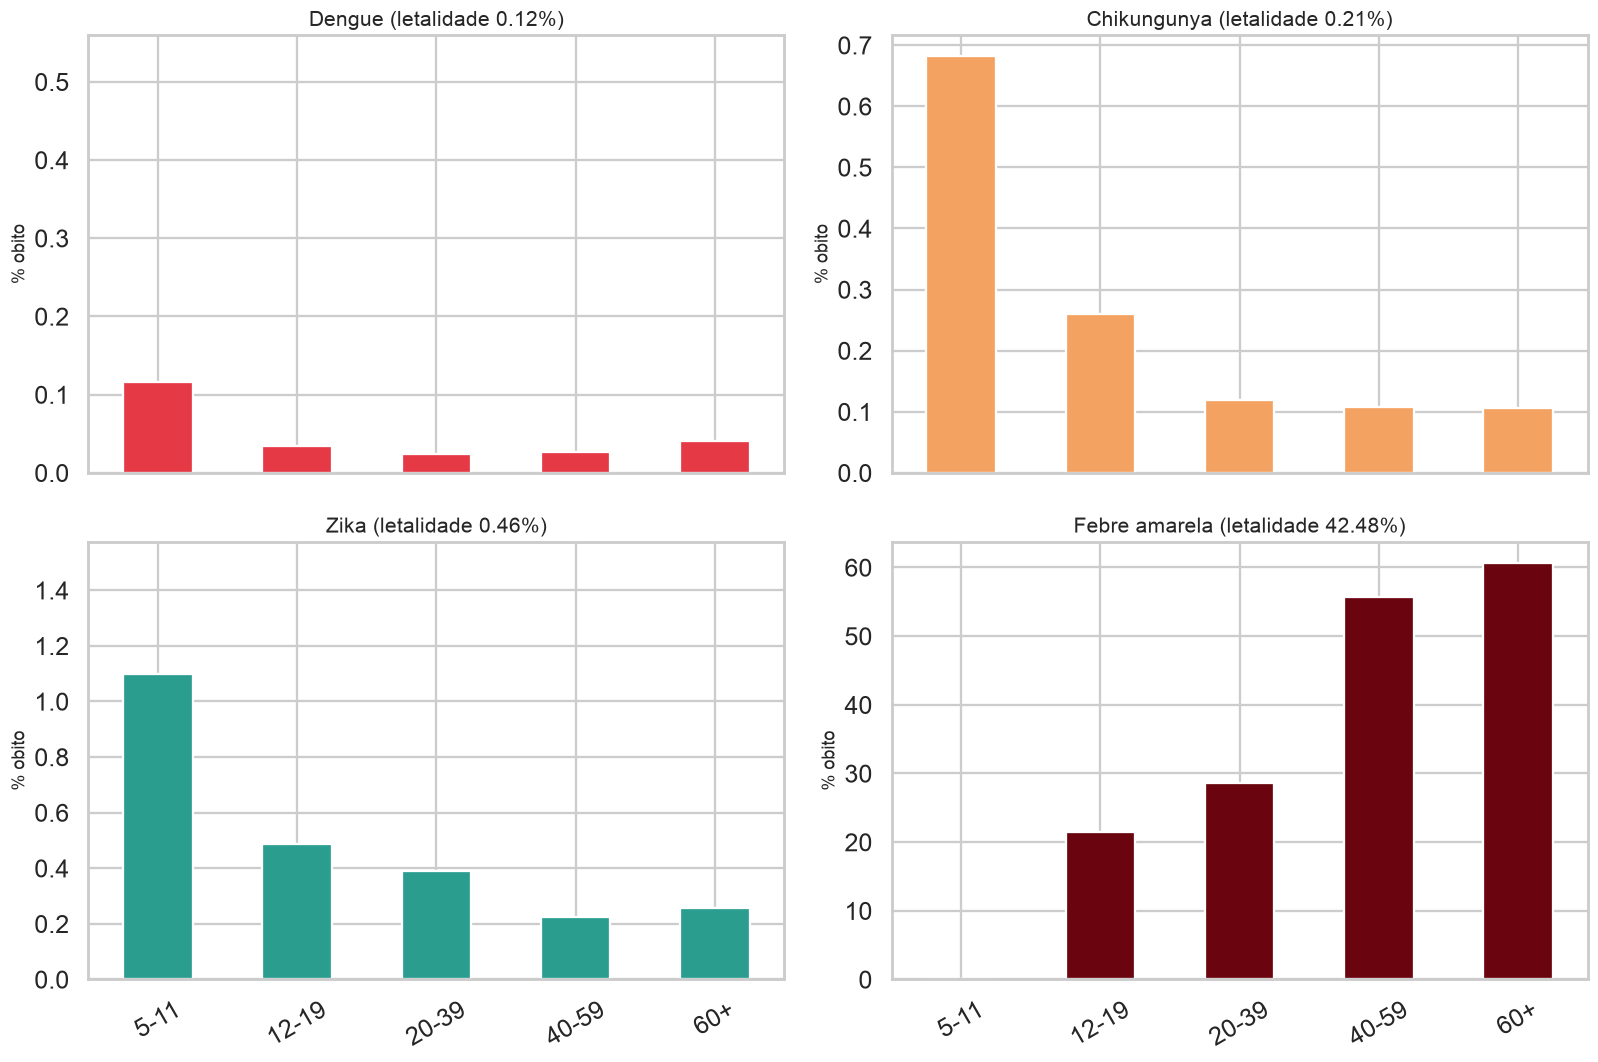

In [42]:
q9 = (df.dropna(subset=["faixa_etaria"]).groupby(["doenca", "faixa_etaria"], observed=True)
      ["obito"].agg(["size", "mean"]).reset_index())
q9["pct_obito"] = q9["mean"] * 100

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
for ax, doenca in zip(axes.ravel(), ORDEM_DOENCAS):
    sub = q9[q9["doenca"] == doenca].sort_values("faixa_etaria")
    if sub.empty:
        ax.set_visible(False)
        continue
    letalidade_geral = (sub["mean"] * sub["size"]).sum() / sub["size"].sum() * 100
    sub.set_index("faixa_etaria")["pct_obito"].plot(kind="bar", ax=ax, color=CORES_DOENCA[doenca])
    ax.set(title=f"{ROTULO_DOENCA[doenca]} (letalidade {letalidade_geral:.2f}%)", ylabel="% obito", xlabel="")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

> **Leitura esperada:** dengue/chikungunya/zika tendem a curvas baixas e relativamente planas; febre amarela tende a uma curva alta e crescente com idade. Se as formas diferem, a resposta à pergunta central é "cada doença tem assinatura própria".

## 11. Inferência estatística consolidada (dengue + chikungunya)

Odds ratio por comorbidade (crosstab 2x2 + IC 95%), teste de tendência dose-resposta (Cochran-Armitage) e regressão logística multivariada.

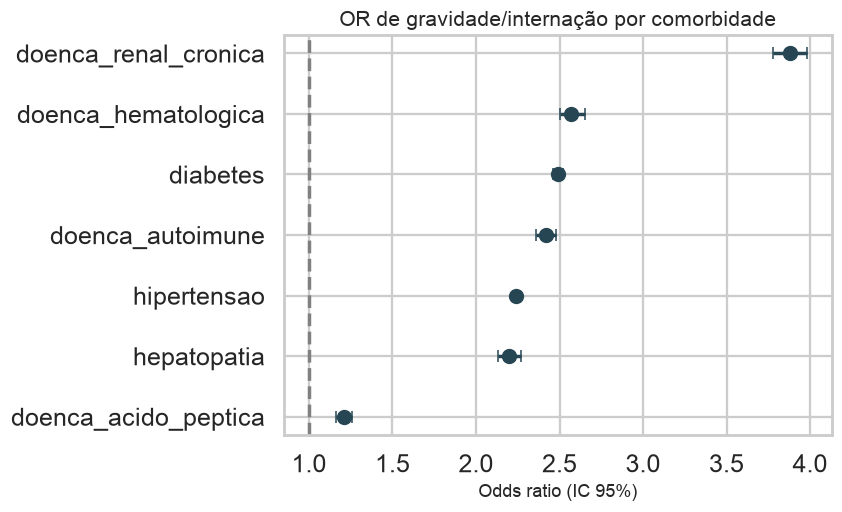

,comorbidade,OR,IC95%_low,IC95%_high
5,doenca_acido_peptica,1.21,1.16,1.26
2,hepatopatia,2.20,2.13,2.27
1,hipertensao,2.24,2.22,2.26
6,doenca_autoimune,2.42,2.36,2.48
0,diabetes,2.49,2.46,2.52
4,doenca_hematologica,2.57,2.50,2.65
3,doenca_renal_cronica,3.88,3.78,3.98


In [43]:
def odds_ratio_ic(a, b, c, d):
    if 0 in (a, b, c, d):
        a, b, c, d = a + .5, b + .5, c + .5, d + .5
    orr = (a * d) / (b * c)
    se = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    li, ls = np.exp(np.log(orr) - 1.96 * se), np.exp(np.log(orr) + 1.96 * se)
    return orr, li, ls


linhas_or = []
for comorb in COLUNAS_COMORBIDADE:
    tab = pd.crosstab(base_q1[comorb] == True, base_q1["grave_ou_internado"])  # noqa: E712
    a = tab.loc[True, True] if (True in tab.index and True in tab.columns) else 0
    b = tab.loc[True, False] if (True in tab.index and False in tab.columns) else 0
    c = tab.loc[False, True] if (False in tab.index and True in tab.columns) else 0
    d = tab.loc[False, False] if (False in tab.index and False in tab.columns) else 0
    orr, li, ls = odds_ratio_ic(a, b, c, d)
    linhas_or.append({"comorbidade": comorb, "OR": round(orr, 2),
                       "IC95%_low": round(li, 2), "IC95%_high": round(ls, 2)})

df_or = pd.DataFrame(linhas_or).sort_values("OR")

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(df_or))
ax.errorbar(df_or["OR"], y, xerr=[df_or["OR"] - df_or["IC95%_low"], df_or["IC95%_high"] - df_or["OR"]],
            fmt="o", color="#264653", capsize=4)
ax.axvline(1, linestyle="--", color="gray")
ax.set_yticks(y); ax.set_yticklabels(df_or["comorbidade"])
ax.set(xlabel="Odds ratio (IC 95%)", title="OR de gravidade/internação por comorbidade")
plt.tight_layout(); plt.show()
df_or

In [44]:
tabela_ca = base_q1.groupby("n_comorbidades")["grave_ou_internado"].agg(["size", "sum"]).reset_index()
niveis = tabela_ca["n_comorbidades"].to_numpy(dtype=float)
n_i = tabela_ca["size"].to_numpy(dtype=float)
casos = tabela_ca["sum"].to_numpy(dtype=float)

N, R = n_i.sum(), casos.sum()
p_bar = R / N
media_niveis = np.average(niveis, weights=n_i)
num = (n_i * (casos / n_i - p_bar) * niveis).sum() ** 2
den = p_bar * (1 - p_bar) * (n_i * (niveis - media_niveis) ** 2).sum()
estat_ca = num / den
p_ca = 1 - chi2_dist.cdf(estat_ca, df=1)
print(f"Cochran-Armitage (tendencia dose-resposta): qui2={estat_ca:.2f}, p={p_ca:.4g}")

Cochran-Armitage (tendencia dose-resposta): qui2=51229.43, p=0


> **Por que a multivariada importa:** o OR bruto de comorbidade pode estar inflado porque comorbidade anda junto com idade. A regressão ajustada mostra o efeito de `n_comorbidades` mantendo idade, sexo e doença constantes.

In [45]:
base_mv = base_q1.dropna(subset=["idade", "sexo", "n_comorbidades"]).copy()
base_mv["alvo"] = base_mv["grave_ou_internado"].astype(int)
base_mv["sexo_bin"] = (base_mv["sexo"] == "masculino").astype(int)

modelo_mv = smf.logit("alvo ~ n_comorbidades + idade + sexo_bin + C(doenca)", data=base_mv).fit(disp=0)
res_mv = pd.DataFrame({
    "OR": np.exp(modelo_mv.params),
    "IC95%_low": np.exp(modelo_mv.conf_int()[0]),
    "IC95%_high": np.exp(modelo_mv.conf_int()[1]),
    "p_valor": modelo_mv.pvalues,
}).round(3)
res_mv

,OR,IC95%_low,IC95%_high,p_valor
Intercept,0.015,0.015,0.015,0.0
C(doenca)[T.dengue],1.566,1.542,1.589,0.0
n_comorbidades,1.438,1.432,1.444,0.0
idade,1.008,1.008,1.008,0.0
sexo_bin,1.082,1.075,1.089,0.0
